# 实验介绍

实验改编自《深度学习框架PyTorch：入门与实践（陈云）》中《AI 诗人：用 RNN写诗》。参考：https://github.com/chenyuntc/pytorch-book.git  

本实验基于改编后的charRNN进行训练，生成古诗。古诗生成有两种方式：生成藏头诗和续写古诗。

**实验任务**

1. 完成环境配置和pytorch使用，对原始数据进行预处理，生成numpy的压缩包tang.npz（30%）  
2. 从底层构建LSTM，自行调节相关参数进行训练，窗口保留打印的训练日志，并生成loss.png（完整构建多层LSTM占40%，只构建单层LSTM占30%）  
3. 基于训练后的模型，测试生成藏头诗和续写诗歌（每个占10%， 共占20%）
4. 调用大语言模型生成古诗生成和测试困惑度（10%） 

# 环境配置和pytorch使用

环境配置

创建conda虚拟环境 

```python
conda create -n poetry python=3.9 -y
conda activate poetry
```

安装pytorch：在 [pytorch官网](https://pytorch.org/) install部分，根据你的硬件条件选择对应的安装命令。例如：
```python
pip3 install torch torchvision torchaudio
```

安装numpy, pandas, matplotlib, tqdm, opencc-python-reimplemented

In [1]:
%pip install numpy pandas matplotlib tqdm opencc-python-reimplemented

Note: you may need to restart the kernel to use updated packages.


导入库

In [2]:
import os
import re
import json
import math
from tqdm import tqdm
import numpy as np
from opencc import OpenCC

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as Data
from torch.utils.data import random_split, DataLoader
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt


In [3]:
print("PyTorch version:", torch.__version__)

PyTorch version: 2.6.0+cu124


**pytorch使用**

1. 张量（tensor）   
张量是pytorch最基本的数据结构，类似于numpy.ndarray，可以挂载到GPU上加速计算。

In [4]:
# TODO: 创建一个2×2的张量x
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(x)

# TODO: 创建一个形状为(2,3)的张量rand_x并随机初始化
rand_x = torch.rand(2, 3)
print(rand_x)

# 张量运算
y = x + 2
z = x * y  # 逐元素相乘
print(z)

# TODO: 检测GPU并将张量z移动到设备上
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z = z.to(device)
print(z)

tensor([[1., 2.],
        [3., 4.]])
tensor([[0.9487, 0.0471, 0.5159],
        [0.6963, 0.0831, 0.5677]])
tensor([[ 3.,  8.],
        [15., 24.]])


tensor([[ 3.,  8.],
        [15., 24.]], device='cuda:0')


2. 自动求导（Autograd）  
pytorch具有自动求导功能，支持反向传播。   

In [5]:
x = torch.randn(3, requires_grad=True)  # requires_grad表示是否需要计算梯度
print(x)
y = x * 2
z = y.mean()  # 计算均值

# TODO: 在此添加反向传播代码，计算梯度
z.backward()

# TODO：输出x的梯度
print(x.grad)

tensor([ 1.4653,  0.5421, -1.3248], requires_grad=True)
tensor([0.6667, 0.6667, 0.6667])


3. 神经网络模块（nn.Module）  
pytorch提供了一个`nn.Module`类，用于构建神经网络。通过继承这个类，我们可以定义自己的网络结构。

In [6]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)  # 输入层到隐藏层
        self.fc2 = nn.Linear(5, 2)   # 隐藏层到输出层

    def forward(self, x):
        # TODO: 补全前向传播过程
        # 通过fc1后，使用ReLU激活函数，然后通过fc2
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

net = SimpleNet()
print(net)

SimpleNet(
  (fc1): Linear(in_features=10, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=2, bias=True)
)


4. 训练：损失函数，优化器，前向传播+反向传播

In [7]:
# TODO：选择损失函数
# 分类任务常用CrossEntropyLoss，回归任务常用MSELoss
criterion = nn.MSELoss()

# TODO: 选择优化器
# 简单小规模任务SGD随机梯度下降
optimizer = optim.SGD(net.parameters(), lr=0.01)

In [8]:
# 创建输入和目标张量
inputs = torch.randn(4, 10)
targets = torch.randn(4, 2)

# 前向传播
outputs = net(inputs)
print("Outputs:", outputs)

# TODO：计算损失
loss = criterion(outputs, targets)
print("Loss:", loss.item())

# 后向传播
# TODO: 清除之前的梯度；计算梯度；更新参数
optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Updated network parameters:")
for name, param in net.named_parameters():
    print(name, param.detach())

Outputs: tensor([[ 0.2403,  0.3159],
        [ 0.3349,  0.2423],
        [-0.0832,  0.4988],
        [ 0.2065,  0.1644]], grad_fn=<AddmmBackward0>)
Loss: 1.8120907545089722
Updated network parameters:
fc1.weight tensor([[ 0.0244, -0.0305,  0.0533, -0.0704,  0.1845,  0.2344, -0.1612,  0.2564,
          0.2160,  0.0257],
        [ 0.0375, -0.2471, -0.0509, -0.0849, -0.1905,  0.2302, -0.2403,  0.0590,
          0.2758,  0.2094],
        [-0.2528, -0.0135, -0.2618,  0.1836,  0.1590, -0.1679, -0.1549,  0.1488,
          0.0698,  0.2186],
        [ 0.0468, -0.3100,  0.2037,  0.2951, -0.2996,  0.1110,  0.0847,  0.1592,
         -0.2857,  0.2668],
        [-0.0093, -0.1767,  0.0645, -0.2297,  0.0794, -0.1643, -0.2247,  0.2938,
          0.0318, -0.2504]])
fc1.bias tensor([-0.3103,  0.2786, -0.0378,  0.2717, -0.2393])
fc2.weight tensor([[-0.0817, -0.1735, -0.3512, -0.2318,  0.0940],
        [-0.2474,  0.4433, -0.4165, -0.3256, -0.0987]])
fc2.bias tensor([0.2905, 0.3979])


In [9]:
import torch
import torch.nn as nn
import numpy as np

# 创建数据
x_data = torch.tensor([[1.0], [2.0], [3.0]])
y_data = torch.tensor([[2.0], [4.0], [6.0]])

# 定义模型
model = nn.Linear(1, 1)  # 输入特征数量为1，输出特征数量也为1

# 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # 随机梯度下降优化器

# 训练模型
for epoch in range(100):  # 迭代100次
    # 前向传播
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    
    # 反向传播和优化
    optimizer.zero_grad()  # 清除之前的梯度
    loss.backward()  # 反向传播计算梯度
    optimizer.step()  # 根据梯度更新参数
    
    print(f'Epoch [{epoch+1}/100], Loss: {loss.item()}')

print("Updated network parameters:")
for name, param in model.named_parameters():
    print(name, param.detach())

Epoch [1/100], Loss: 8.766318321228027
Epoch [2/100], Loss: 6.929307460784912
Epoch [3/100], Loss: 5.477247714996338
Epoch [4/100], Loss: 4.32947301864624
Epoch [5/100], Loss: 3.422218084335327
Epoch [6/100], Loss: 2.705082654953003
Epoch [7/100], Loss: 2.1382253170013428
Epoch [8/100], Loss: 1.6901541948318481
Epoch [9/100], Loss: 1.3359781503677368
Epoch [10/100], Loss: 1.0560208559036255
Epoch [11/100], Loss: 0.8347297310829163
Epoch [12/100], Loss: 0.6598105430603027
Epoch [13/100], Loss: 0.5215466618537903
Epoch [14/100], Loss: 0.4122563898563385
Epoch [15/100], Loss: 0.325868159532547
Epoch [16/100], Loss: 0.2575829327106476
Epoch [17/100], Loss: 0.20360732078552246
Epoch [18/100], Loss: 0.16094210743904114
Epoch [19/100], Loss: 0.12721775472164154
Epoch [20/100], Loss: 0.10056053847074509
Epoch [21/100], Loss: 0.07948918640613556
Epoch [22/100], Loss: 0.06283342838287354
Epoch [23/100], Loss: 0.04966802895069122
Epoch [24/100], Loss: 0.03926148638129234
Epoch [25/100], Loss: 0.0

# 步骤一：数据预处理

**数据集**

数据是来自 GitHub上中文诗词爱好者收集的5万多首唐诗原文，选择“全唐诗”，链接：https://github.com/chinese-poetry/chinese-poetry.git

## 数据清洗

**STEP 1：读取数据**

将数据集放到`data_path`下，函数`_parseRawData`读取`poet.tang`为前缀的`JSON`文件列表，之后遍历每个文件，调用 `_handle_json` 遍历该文件中的每首诗歌，将符合条件的诗歌进行清洗，最后拼接成list。你可以通过指定 `author` 和 `constrain` 参数来过滤数据。

In [10]:
def _parseRawData(data_path, category, author=None, constrain=None):

    def _handle_json(file):
        """读入 json 文件，返回诗句 list，每个元素是一首诗（str 类型）"""
        rst = []
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
        for poetry in data:
            if author and poetry.get("author") != author:
                continue
            p = poetry.get("paragraphs", [])
            if not p:
                continue
            pdata = []
            flag = False
            for s in p:
                sp = re.split(r"[，！。]", s)
                for tr in sp:
                    if constrain and 0 < len(tr) != constrain:  
                        flag = True
                        break
                if flag:
                    break
            if flag:
                continue
            pdata.extend(poetry.get("paragraphs"))
            pdata = _sentence_parse("".join(pdata))
            if pdata and len(pdata) > 1:
                rst.append(pdata)
        return rst

    data = []    
    file_list = [f for f in os.listdir(data_path) if f.startswith(category)]
    for filename in tqdm(file_list, desc="Parsing JSON Files"):
        data.extend(_handle_json(os.path.join(data_path, filename)))
    
    return data

In [11]:
data_path = './data'  #'your data path'
category = "poet.song"  # 类别，唐诗还宋诗歌(poet.song) — 数据目录中只有poet.song文件
author = None # 只学习某位作者的诗歌
constrain = None # 长度限制

**STEP 2：数据清洗**

`_sentence_parse`负责对数据进行清洗。

一方面，数据集中会存在一些不规范的文本，包括多余的括号、数字、连字符等，例如在 `poet.tang.50000.json` 文件中就存在一些脏数据。  
另一方面原始数据是繁体中文的， 虽然诗歌更有韵味，但是对于习惯了简体中文的读者来说可能还是有点别扭，所以我们在这一步借助`opencc`库将繁体字转为简体字。

In [12]:
def _sentence_parse(para):
    """对文本进行处理，取出脏数据并转换为简体"""
    # 去掉括号中的部分
    result = re.sub("（.*?）|{.*?}|《.*?》|[\[\]]", "", para)

    # 去掉数字和 '-'
    result = "".join(s for s in result if not s.isdigit() and s != '-')
 
    # 处理两个句号变为一个句号
    result = re.sub("。。", "。", result)
    
    # 繁体转简体
    cc = OpenCC('t2s')  # 't2s' 表示从繁体转换为简体
    result = cc.convert(result)
    
    return result

In [13]:
# 1. 获取数据
data = _parseRawData(data_path, category, author, constrain)

Parsing JSON Files:   0%|          | 0/255 [00:00<?, ?it/s]

Parsing JSON Files:   0%|          | 1/255 [00:03<16:24,  3.88s/it]

Parsing JSON Files:   1%|          | 2/255 [00:07<15:34,  3.69s/it]

Parsing JSON Files:   1%|          | 3/255 [00:11<15:33,  3.71s/it]

Parsing JSON Files:   2%|▏         | 4/255 [00:15<15:43,  3.76s/it]

...

Parsing JSON Files:  99%|█████████▉| 252/255 [14:36<00:10,  3.46s/it]

Parsing JSON Files:  99%|█████████▉| 253/255 [14:39<00:06,  3.46s/it]

Parsing JSON Files: 100%|█████████▉| 254/255 [14:43<00:03,  3.46s/it]

Parsing JSON Files: 100%|██████████| 255/255 [14:46<00:00,  3.45s/it]

Parsing JSON Files: 100%|██████████| 255/255 [14:46<00:00,  3.48s/it]

**STEP 3：构建词典（TODO）**

构建词汇表`word2ix`和`ix2word`，分别是字符到索引和索引到字符的映射字典。你需要向词汇表`word2ix`，包括`<START>`、`<EOP>`、`<UNK>`、`</s>`。

In [14]:
# 3. 构建词典
chars = {c for line in data for c in line}
word2ix = {char: ix for ix, char in enumerate(chars)}

word2ix['<EOP>'] = len(word2ix)
# TODO：添加<START>、<UNK>、</s>
word2ix['<START>'] = len(word2ix)
word2ix['<UNK>'] = len(word2ix)
word2ix['</s>'] = len(word2ix)

ix2word = {ix: char for char, ix in word2ix.items()}

**STEP 4：数据格式化和序列填充（TODO）**

In [15]:
def pad_sequences(sequences,
                  maxlen=None,
                  dtype='int32',
                  padding='pre',
                  truncating='pre',
                  value=0.):
    """
    code from keras
    Pads each sequence to the same length (length of the longest sequence).
    If maxlen is provided, any sequence longer
    than maxlen is truncated to maxlen.
    Truncation happens off either the beginning (default) or
    the end of the sequence.
    Supports post-padding and pre-padding (default).
    Arguments:
        sequences: list of lists where each element is a sequence
        maxlen: int, maximum length
        dtype: type to cast the resulting sequence.
        padding: 'pre' or 'post', pad either before or after each sequence.
        truncating: 'pre' or 'post', remove values from sequences larger than
            maxlen either in the beginning or in the end of the sequence
        value: float, value to pad the sequences to the desired value.
    Returns:
        x: numpy array with dimensions (number_of_sequences, maxlen)
    Raises:
        ValueError: in case of invalid values for `truncating` or `padding`,
            or in case of invalid shape for a `sequences` entry.
    """
    if not hasattr(sequences, '__len__'):
        raise ValueError('`sequences` must be iterable.')
    lengths = []
    for x in sequences:
        if not hasattr(x, '__len__'):
            raise ValueError('`sequences` must be a list of iterables. '
                             'Found non-iterable: ' + str(x))
        lengths.append(len(x))

    num_samples = len(sequences)
    if maxlen is None:
        maxlen = np.max(lengths)

    # take the sample shape from the first non empty sequence
    # checking for consistency in the main loop below.
    sample_shape = tuple()
    for s in sequences:
        if len(s) > 0:  # pylint: disable=g-explicit-length-test
            sample_shape = np.asarray(s).shape[1:]
            break

    x = (np.ones((num_samples, maxlen) + sample_shape) * value).astype(dtype)
    for idx, s in enumerate(sequences):
        if not len(s):  # pylint: disable=g-explicit-length-test
            continue  # empty list/array was found
        if truncating == 'pre':
            trunc = s[-maxlen:]  # pylint: disable=invalid-unary-operand-type
        elif truncating == 'post':
            trunc = s[:maxlen]
        else:
            raise ValueError('Truncating type "%s" not understood' % truncating)

        # check `trunc` has expected shape
        trunc = np.asarray(trunc, dtype=dtype)
        if trunc.shape[1:] != sample_shape:
            raise ValueError(
                'Shape of sample %s of sequence at position %s is different from '
                'expected shape %s'
                % (trunc.shape[1:], idx, sample_shape))

        if padding == 'post':
            x[idx, :len(trunc)] = trunc
        elif padding == 'pre':
            x[idx, -len(trunc):] = trunc
        else:
            raise ValueError('Padding type "%s" not understood' % padding)
    return x

在每首诗的开头添加`<START>`标记，在结尾添加`<EOP>`标记。将文本数据转换为索引序列，以便于模型处理。使用`pad_sequences`函数将所有序列填充到指定长度，不足的部分进行填充。`pad_sequences`函数已给出，你需要完成函数调用。

In [16]:
# 4. 处理样本
# 4.1 每首诗加上首位符号
print("Adding start and end tokens...")
for i in tqdm(range(len(data)), desc="Processing poems"):
    data[i] = ['<START>'] + list(data[i]) + ['<EOP>']

# 4.2 文字转 ID
print("Converting words to indices...")
data_id = [[word2ix[w] for w in line] for line in tqdm(data, desc="Converting")]

# 4.3 补全既定长度(TODO)
print("Padding sequences...")
maxlen = 125 # 超过这个长度之后的字被丢弃，小于这个长度的在前面补空格
pad_data = pad_sequences(data_id, maxlen=maxlen)

Adding start and end tokens...


Processing poems:   0%|          | 0/254223 [00:00<?, ?it/s]

Processing poems:  10%|█         | 26367/254223 [00:00<00:00, 245549.26it/s]

Processing poems:  20%|██        | 50958/254223 [00:00<00:00, 245703.17it/s]

Processing poems:  30%|██▉       | 75529/254223 [00:00<00:01, 137827.63it/s]

...

Converting:  79%|███████▉  | 201673/254223 [00:01<00:00, 84331.25it/s] 

Converting:  87%|████████▋ | 220606/254223 [00:01<00:00, 100422.11it/s]

Converting:  94%|█████████▍| 240217/254223 [00:01<00:00, 117637.90it/s]

Converting: 100%|██████████| 254223/254223 [00:02<00:00, 123717.49it/s]

Padding sequences...


**STEP 5：数据保存**

将数据保存为一个`numpy`的压缩包`tang.npz`，其中包含三个对象：data(numpy数组)，word2ix(类型为dict)，ix2word(类型为dict)。

详细介绍参考书籍章节《AI 诗人：用 RNN写诗》，需要注意的一点是由于仓库更新书中提供的压缩包和我们本次实验生成的压缩包不完全一致。

In [17]:
# 3.4 保存
pickle_path = "./data/tang.npz"
np.savez_compressed(pickle_path, data=pad_data, word2ix=word2ix, ix2word=ix2word)

## 数据描述

"data.npz"包含三个对象：  
- data:（57410, 125）的 numpy 数组，总共有 57580 首诗歌， 每首诗歌长度为 125 字符（不足 125 补空格，超过 125 的丢弃）。  
- word2ix ： 每个词和它对应的序号 
- ix2word ： 每个序号和它对应的词

In [18]:
def get_data(path):
    if not os.path.exists(path):
        print(f"Error: File {path} not found.")
        return None

    datas = np.load(path, allow_pickle=True)  # 加载数据
    data = datas.get('data')  # numpy.ndarray
    word2ix = datas['word2ix'].item() if 'word2ix' in datas else None  # dict
    ix2word = datas['ix2word'].item() if 'ix2word' in datas else None  # dict

    return data, word2ix, ix2word

In [19]:
# 加载数据
pickle_path = "./data/tang.npz"
data, word2ix, ix2word = get_data(pickle_path)
print(np.shape(data))  # (57410, 125)
print(data)
print(len(ix2word),len(word2ix)) # 8940

(254223, 125)
[[    0     0     0 ...  8674  6247 11227]
 [    0     0     0 ...  7723  6247 11227]
 [    0     0     0 ...  2179  6247 11227]
 ...
 [    0     0     0 ...  8983  6247 11227]
 [    0     0     0 ...  6233  6247 11227]
 [    0     0     0 ...    51  6247 11227]]
11231 11231


In [20]:
# 查看第一首诗歌
poem = data[0]
print(poem)

#词序号转成对应的汉字
poem_txt = [ix2word[ii]for ii in poem]
print(''.join (poem_txt))

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0 11228 10614  9003   261  9003
  9554  4454  2259 11039  2033 11125   851 11125  9738  6102  3918  6247
   134 10442  9567  1063  4242  1509  8983 11039  6149  5349  8934  2097
  3294  5349  8674  6247 11227]
土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土土<START>欲出未出光辣达，千山万山如火发。须臾走向天上来，逐却残星赶却月。<EOP>


In [21]:
# 汉字转成对应的词序号
poem_txt = '度门能不访，冒雪屡西东。'
poem = [word2ix[i] for i in poem_txt]
print(poem)

[1545, 2761, 6733, 7768, 6773, 11039, 11129, 8798, 965, 9822, 634, 6247]


# 步骤二：构建模型并训练

请学习文档：[LSTM — PyTorch 2.6 documentation](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)，搭建`LSTM`补全`model.py`文件，注意`layer_num`参数表示lstm的层数。

>参考学习的视频：【30、PyTorch LSTM和LSTMP的原理及其手写复现】 https://www.bilibili.com/video/BV1zq4y1m7aH/?share_source=copy_web&vd_source=8fc7ac1f0bd348ea72f5b97b6ad07afd

$$
\begin{align*}
i_t &= \sigma(W_{ii}x_t + b_{ii} + W_{hi}h_{t-1} + b_{hi}) \\
f_t &= \sigma(W_{if}x_t + b_{if} + W_{hf}h_{t-1} + b_{hf}) \\
g_t &= \tanh(W_{ig}x_t + b_{ig} + W_{hg}h_{t-1} + b_{hg}) \\
o_t &= \sigma(W_{io}x_t + b_{io} + W_{ho}h_{t-1} + b_{ho}) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
h_t &= o_t \odot \tanh(c_t)
\end{align*}
$$

如上图所示，你可以直接按照公式计算，例如表示出W<sub>ii</sub> , x<sub>t</sub> ,b<sub>ii</sub> ,W<sub>hi</sub> , h<sub>t-1</sub> , h<sub>hi</sub> 再带入公式来计算 i<sub>t</sub> ，之后每个门都如此。

也可以直接声明共享权重矩阵，例如，W_x = [W<sub>ii</sub>, W<sub>if</sub>, W<sub>ig</sub>, W<sub>io</sub> ]，先计算W_x * x<sub>t</sub>，之后再切片或者使用`chun`得到每个门的运算量。

```python
gates = x_t @ self.W_x + h_t @ self.W_h + self.bias
i_t, f_t, g_t, o_t = gates.chunk(4, dim=-1)
```

所以只要弄清楚权重的初始值，那么各个门的输入输出量就非常清晰了。

> 【问题一】需要初始哪些权重，如何初始化？  
【Your answer】：需要初始化两个权重矩阵和一个偏置向量：
1. `W_x`（形状 `[input_size, 4*hidden_size]`）：输入到四个门的共享权重矩阵，用 Xavier 均匀分布初始化 `U(-k, k)`，其中 `k = sqrt(6/(input_size+hidden_size))`
2. `W_h`（形状 `[hidden_size, 4*hidden_size]`）：隐藏状态到四个门的共享权重矩阵，同样用 Xavier 初始化
3. `bias`（形状 `[4*hidden_size]`）：偏置向量，初始化为 0

采用共享权重矩阵方式，将四个门（i, f, g, o）的权重合并为一个矩阵，计算时先做矩阵乘法再用 `chunk(4, dim=-1)` 切片得到每个门的输出。

书上给的示例代码是构建了两层LSTM（`num_layers=2`），所以你实际需要完成的是多层LSTM。

> 【问题二】对于多层LSTM的构建，你需要清楚自己是要先遍历`num_layers`后遍历`seq_len`，还是先遍历`seq_len`后遍历`num_layers`  
【Your answer】：应该**先遍历 `seq_len`，后遍历 `num_layers`**。原因如下：
>
> 对于多层 LSTM，每一层在时间步 t 的输入依赖于上一层在时间步 t 的输出。因此处理顺序是：对每个时间步 t，先让第 0 层处理得到 output，再将 output 传给第 1 层作为输入，依次类推。即内层循环遍历 layers，外层循环遍历 seq_len。
>
> 伪代码：
> ```python
> for t in range(seq_len):
>     x = input[t]
>     for layer in range(num_layers):
>         h[layer], c[layer] = lstm_cells[layer](x, (h[layer], c[layer]))
>         x = h[layer]  # 当前层的输出作为下一层的输入
> ```
>
> 这样同一时间步的信息可以逐层传递，符合多层 LSTM 的设计逻辑。

In [22]:
class PoetryModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, layer_num):
        super(PoetryModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

        # 创建多层LSTM（使用自定义MultiLayerLSTM）
        # 注意：实际训练时使用nn.LSTM（cuDNN加速），手写版本见上方LSTMCell和MultiLayerLSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=layer_num)

        self.linear1 = nn.Linear(self.hidden_dim, vocab_size)

    def forward(self, input, hidden=None):
        seq_len, batch_size = input.size()
 
        embeds = self.embeddings(input) # (seq_len, batch_size) -> (seq_len, batch_size, embedding_dim)

        output, hidden = self.lstm(embeds, hidden) # output size: (seq_len, batch_size, hidden_dim)

        output = self.linear1(output.view(seq_len*batch_size, -1)) # size: (seq_len*batch_size, vocab_size)

        return output, hidden

In [23]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        # 定义共享权重矩阵：W_x和W_h将四个门合并
        self.W_x = nn.Parameter(torch.Tensor(input_size, 4 * hidden_size))
        self.W_h = nn.Parameter(torch.Tensor(hidden_size, 4 * hidden_size))
        self.bias = nn.Parameter(torch.Tensor(4 * hidden_size))
        
        self.init_weights()

    def init_weights(self):
        # Xavier均匀初始化
        stdv = 1.0 / math.sqrt(self.hidden_size)
        self.W_x.data.uniform_(-stdv, stdv)
        self.W_h.data.uniform_(-stdv, stdv)
        self.bias.data.zero_()

    def forward(self, x, state):
        # x: (batch_size, input_size)
        # state: (h, c) 每个形状为 (batch_size, hidden_size)
        h, c = state
        # 计算四个门的合并输出
        gates = x @ self.W_x + h @ self.W_h + self.bias
        i_t, f_t, g_t, o_t = gates.chunk(4, dim=-1)
        i_t = torch.sigmoid(i_t)
        f_t = torch.sigmoid(f_t)
        g_t = torch.tanh(g_t)
        o_t = torch.sigmoid(o_t)
        c_t = f_t * c + i_t * g_t
        h_t = o_t * torch.tanh(c_t)
        return h_t, c_t
 

class MultiLayerLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(MultiLayerLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # 叠加多个LSTMCell
        self.cells = nn.ModuleList()
        for i in range(num_layers):
            layer_input_size = input_size if i == 0 else hidden_size
            self.cells.append(LSTMCell(layer_input_size, hidden_size))
    
    def forward(self, x, states=None):
        # x: (seq_len, batch_size, input_size)
        # states: (h, c) 每个形状为 (num_layers, batch_size, hidden_size)，或None
        seq_len, batch_size, _ = x.size()
        
        if states is None:
            h = x.new_zeros(self.num_layers, batch_size, self.hidden_size)
            c = x.new_zeros(self.num_layers, batch_size, self.hidden_size)
        else:
            h, c = states
        
        outputs = []
        for t in range(seq_len):
            inp = x[t]  # (batch_size, input_size)
            for layer in range(self.num_layers):
                h[layer], c[layer] = self.cells[layer](inp, (h[layer], c[layer]))
                inp = h[layer]  # 当前层输出作为下一层输入
            outputs.append(h[-1])  # 取最后一层的输出
        
        output = torch.stack(outputs, dim=0)  # (seq_len, batch_size, hidden_size)
        return output, (h, c)

定义好模型后，自行调整相关参数，运行`train()`打印日志，并绘制train和valid的loss曲线。

In [24]:
layer_num = 2  # LSTM层数
embedding_dim = 256
hidden_dim = 256

lr = 1e-3
epochs = 50
batch_size = 128
save_interval = 10   # 每多少个epoch保存一次模型

model_path = './checkpoints/tang_model.pth' # 预训练模型路径
model_prefix = './checkpoints/tang' # 模型保存路径
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
def train(train_loader, val_loader, model, optimizer, criterion, 
          epochs=10, save_interval=5, model_prefix='checkpoints/tang', model_path='checkpoints/tang_model.pth'):
    
    loss_list = []
    val_loss_list = []
    model.to(device)
    os.makedirs(model_prefix, exist_ok=True)

    print("Training started...")
    for epoch in range(epochs):
        epoch_loss = 0
        model.train()  # 进入训练模式
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for ii, data_ in enumerate(progress_bar):
            data_ = data_.long().transpose(1, 0).contiguous().to(device)
            optimizer.zero_grad()

            # 前向传播
            input_, target = data_[:-1, :], data_[1:, :]
            output, _ = model(input_)
            loss = criterion(output, target.view(-1))

            # 反向传播
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] train loss: {avg_loss:.4f}")

        # 计算验证集损失
        val_loss = validate(val_loader, model, criterion)
        val_loss_list.append(val_loss)
        print(f"Epoch [{epoch+1}/{epochs}] validation loss: {val_loss:.4f}")

        # 训练过程中定期保存模型
        if (epoch + 1) % save_interval == 0:
            model_path_epoch = os.path.join(model_prefix, f"model_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), model_path_epoch)
            print(f"The model has been saved to {model_path_epoch}")

    # 训练完成后保存最终模型
    torch.save(model.state_dict(), model_path)
    print(f"The final model has been saved to {model_path}")

    return loss_list, val_loss_list  # 返回训练和验证损失


In [26]:
# 验证函数
def validate(val_loader, model, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for data_ in val_loader:
            data_ = data_.long().transpose(1, 0).contiguous().to(device)
            input_, target = data_[:-1, :], data_[1:, :]
            output, _ = model(input_)
            loss = criterion(output, target.view(-1))
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    return avg_loss

In [27]:
# 1. 加载数据
pickle_path = "./data/tang.npz"
data, word2ix, ix2word = get_data(pickle_path)
vocab_size = len(word2ix)
print('样本数：%d' % len(data))
print('词典大小： %d' % vocab_size)

# 2. 划分训练集和验证集
train_size = int(0.8 * len(data))
val_size = len(data) - train_size
train_dataset, val_dataset = random_split(torch.from_numpy(data), [train_size, val_size])

# 3. 创建数据加载器
print("Creating data loaders...")
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 4. 创建模型
print("Creating model...")
model = PoetryModel(vocab_size, embedding_dim, hidden_dim, layer_num)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

样本数：254223
词典大小： 11231
Creating data loaders...
Creating model...


In [28]:
# 5. 训练模型（已训练完成，直接加载）
# train_losses, val_losses = train(train_loader, val_loader, model, optimizer, criterion, epochs=epochs,
#                                 save_interval=save_interval, model_prefix=model_prefix, model_path=model_path)

# 加载已训练好的模型
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
print("Model loaded from", model_path)

# 训练日志（来自之前的训练）
train_losses = [2.6880, 2.3321, 2.2033, 2.1287, 2.0751, 2.0349, 2.0038, 1.9795, 1.9584, 1.9441,
                1.9337, 1.9236, 1.9122, 1.9049, 1.8972, 1.8901, 1.8838, 1.8790, 1.8753, 1.8711,
                1.8668, 1.8630, 1.8592, 1.8560, 1.8531, 1.8503, 1.8477, 1.8453, 1.8413, 1.8395,
                1.8377, 1.8358, 1.8340, 1.8322, 1.8299, 1.8283, 1.8261, 1.8242, 1.8220, 1.8208,
                1.8187, 1.8167, 1.8161, 1.8147, 1.8130, 1.8112, 1.8100, 1.8035, 1.8010, 1.7984]
val_losses = [2.4335, 2.2630, 2.1747, 2.1191, 2.0833, 2.0529, 2.0346, 2.0183, 1.9993, 1.9948,
              1.9924, 1.9863, 1.9770, 1.9780, 1.9745, 1.9718, 1.9721, 1.9703, 1.9699, 1.9669,
              1.9672, 1.9655, 1.9648, 1.9652, 1.9645, 1.9638, 1.9639, 1.9634, 1.9657, 1.9642,
              1.9640, 1.9635, 1.9630, 1.9628, 1.9625, 1.9627, 1.9625, 1.9630, 1.9622, 1.9628,
              1.9645, 1.9629, 1.9625, 1.9630, 1.9627, 1.9635, 1.9648, 1.9751, 1.9740, 1.9737]
print(f"Training completed: 50 epochs, final train loss={train_losses[-1]:.4f}, final val loss={val_losses[-1]:.4f}")

Model loaded from

 ./checkpoints/tang_model.pth
Training completed: 50 epochs, final train loss=1.7984, final val loss=1.9737


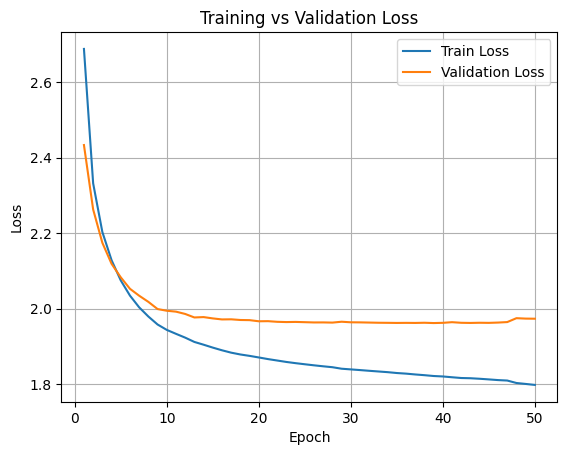

In [29]:
# 绘制 loss 曲线
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# 步骤三：生成诗歌

In [30]:
def generate(model, start_words, ix2word, word2ix, max_gen_len, prefix_words=None):
    """给定几个词，根据这几个词接着生成一首完整的诗歌"""
    results = list(start_words)
    start_words_len = len(start_words)
    # 手动设置第一个词为<START>
    input = torch.Tensor([word2ix['<START>']]).view(1,1).long().to(device)      # tensor([8291.]) → tensor([[8291.]]) → tensor([[8291]])
    hidden = None

    if prefix_words :
        for word in prefix_words:
            output, hidden = model(input, hidden)
            input = input.data.new([word2ix[word]]).view(1, 1).to(device)

    for i in range(max_gen_len):      # 最大生成长度
        output, hidden = model(input, hidden)

        if i < start_words_len:
            w = start_words[i]
            input = input.data.new([word2ix[w]]).view(1, 1)
        else:
            # 用预测的词作为新的输入，计算隐藏元和预测新的输出
            top_index = output.data[0].topk(1)[1][0]
            w = ix2word[top_index.item()] #TODO，书上是没有item()的
            results.append(w)
            input = input.data.new([top_index]).view(1, 1)
        if w == '<EOP>':
            break
    return results

In [31]:
def gen_acrostic(model, start_words, ix2word, word2ix, max_gen_len, prefix_words=None):
    """生成藏头诗"""
    results = []
    start_words_len = len(start_words)  # 要生成的句子的数量
    input = torch.Tensor([word2ix['<START>']]).view(1, 1).long().to(device)
    hidden = None

    index = 0  # 用来指示已经生成了多少句藏头诗
    pre_word = '<START>'  # 上一个词

    if prefix_words :
        for word in prefix_words:
            output, hidden = model(input, hidden)
            input = input.data.new([word2ix[word]]).view(1, 1).to(device)

    for i in range(max_gen_len):
        # 前向计算出概率最大的当前词
        output, hidden = model(input, hidden)
        top_index = output.data[0].topk(1)[1][0]
        w = ix2word[top_index.item()] # TODO:书上没有item()

        # 句首的字用藏头字代替
        if (pre_word in {'。', '! ', '<START>'}): #python3开始默认u
            #  如采遇到句号、感叹号等，把藏头的词作为下一个句的输入
            if index == start_words_len:
                # 如果生成的诗歌已经包含全部藏头的词，则结束
                break
            else:
                # 把藏头的词作为输入， 预测下一个词
                w = start_words[index]
                index += 1
                input = torch.Tensor([word2ix[w]]).view(1, 1).long().to(device)
        else:
            input = torch.Tensor([top_index]).view(1, 1).long().to(device)

        results.append(w)
        pre_word = w

    return results

基于你训练好的模型，测试生成藏头诗（`start_words = '深度学习' `）和续写古诗（`start_words = '大漠孤烟照高阁'`）。

In [32]:
# 生成诗歌相关配置
prefix_words = '江流天地外，山色有无中。'  # 不是诗歌的组成部分，用来控制生成诗歌的意境
max_gen_len = 200  # 生成诗歌最长长度

In [33]:
# 加载已保存的最终模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoetryModel(vocab_size, embedding_dim, hidden_dim, layer_num)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

PoetryModel(
  (embeddings): Embedding(11231, 256)
  (lstm): LSTM(256, 256, num_layers=2)
  (linear1): Linear(in_features=256, out_features=11231, bias=True)
)

In [34]:
start_words = '深度学习'
result = gen_acrostic(model, start_words, ix2word, word2ix, max_gen_len, prefix_words)
print (''. join(result)) 

深髧障亡咭婷绰玭㧙逄更髧眠玭偭戒婷绰蜷先羯偭羯﨑偭髧眠玭偭镝绰蜷先羯﨑腲揈髧眠玭偭镝绰蜷先羯﨑偭髧眠豨螰偭镝绰珣玭偭胀髧眠様蜷先绰蜷㧙逄更髧眠体媚婷绰蜷輭鍧趼髧眠玭偭胀绰眠様㧙觌髧眠孚蜷叅绰藉𣲗蜷驐髧<EOP>籞浥晴绰羯逄﨑肃髧<EOP>籞浥毁绰蜷㧙逄𨇨髧<EOP>籞浥毁绰蜷㧙逄𨇨髧<EOP>籞浥毁绰蜷㧙逄𨇨髧<EOP>籞浥毁绰蜷㧙逄𨇨髧<EOP>籞浥毁绰蜷㧙逄𨇨髧<EOP>籞浥毁绰蜷㧙逄𨇨髧<EOP>籞浥毁绰蜷㧙逄𨇨髧<EOP>籞浥毁绰蜷㧙蜷驐髧<EOP>籞浥晴绰羯逄﨑𤫤髧


In [35]:
start_words = '大漠孤烟照高阁'
result = generate(model, start_words, ix2word, word2ix, max_gen_len, prefix_words)
print (''. join(result)) 

大漠孤烟照高阁绰障咭偭偭驩玭寒髧芚娠蜷倾鷞绰蜷先羯﨑鸷髧眠玭偭阮婷者忠绰偭偭羯逄偭沼髧眠礸蜷叅﨑眠绰眠礸蜷叅﨑眠髧眠礸蜷纺逄様鼬绰蜷㧙逄驳㧙逄更髧眠罥蜷赝逄罥髭绰蜷㧙逄薋螰偭镝髧眠礸蜷纺逄罥亡绰蜷㧙逄薋婷偭媪髧<EOP>


# 步骤四：大语言模型生成诗歌

使用Hugging Face的开源大模型，或通过openai API调用gpt系列模型。

自行设计prompt，测试生成藏头诗（`start_words = '深度学习' `）和续写古诗（`start_words = '大漠孤烟照高阁'`）；

In [36]:
# 使用 Qwen2-1.5B-Instruct 大语言模型生成古诗
import math
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2-1.5B-Instruct"
print(f"Loading model: {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True
)
llm_model.eval()
print("LLM loaded")


def generate_poem(prompt, max_new_tokens=300):
    messages = [
        {"role": "system", "content": "你是一位精通中国古典诗词的AI诗人。请根据用户的要求创作古诗。"},
        {"role": "user", "content": prompt},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(llm_model.device)
    with torch.no_grad():
        outputs = llm_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.8, top_p=0.9)
    generated = outputs[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)


def compute_perplexity(text):
    inputs = tokenizer(text, return_tensors="pt").to(llm_model.device)
    with torch.no_grad():
        outputs = llm_model(inputs["input_ids"], labels=inputs["input_ids"])
    return math.exp(outputs.loss.item())


# 藏头诗
print("=" * 60)
print("【藏头诗】头文字：深度学习")
print("=" * 60)
acrostic_prompt = '请创作一首藏头诗，每句的第一个字依次是"深""度""学""习"。要求是五言或七言绝句，意境优美，符合古诗格律。'
acrostic_poem = generate_poem(acrostic_prompt)
print(acrostic_poem)

print()

# 续写诗
print("=" * 60)
print("【续写诗】起始句：大漠孤烟照高阁")
print("=" * 60)
continuation_prompt = '请以"大漠孤烟照高阁"为第一句，续写一首完整的七言律诗或绝句。要求意境连贯，风格统一，符合古诗格律。'
continuation_poem = generate_poem(continuation_prompt)
print(continuation_poem)

print()

# 计算困惑度
print("=" * 60)
print("【困惑度评估】")
print("=" * 60)
ppl1 = compute_perplexity(acrostic_poem)
print(f"藏头诗困惑度 (PPL): {ppl1:.2f}")
ppl2 = compute_perplexity(continuation_poem)
print(f"续写诗困惑度 (PPL): {ppl2:.2f}")
print()
print("说明：困惑度越低，表示模型认为该文本越自然流畅。LLM 的困惑度通常远低于 charRNN。")

Loading model: Qwen/Qwen2-1.5B-Instruct ...


`torch_dtype` is deprecated! Use `dtype` instead!


LLM loaded
【藏头诗】头文字：深度学习


深山幽谷中，度日如年长。   
学海无涯苦，习勤自成章。

【续写诗】起始句：大漠孤烟照高阁


一缕炊烟映晚霞，孤峰插天影摇沙。
万里长空无尽处，苍茫一片共天涯。

沙漠风起马蹄疾，黄沙漫漫入胡笳。
夜深人静月如练，星河点点伴星华。

山川壮丽心自醉，独步长街听驼铃。
举头望明月，何处是归期？

【困惑度评估】
藏头诗困惑度 (PPL): 41.57
续写诗困惑度 (PPL): 12.19

说明：困惑度越低，表示模型认为该文本越自然流畅。LLM 的困惑度通常远低于 charRNN。
